In [1]:
import onep
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import scipy.stats
% matplotlib inline

UsageError: Line magic function `%` not found.


In [4]:
#Multiple mice
import pickle

# Load the pickle file
with open('/Users/suthardr/Desktop/collection_cxta_fc.pkl', 'rb') as file:
    collection_cxta_fc = pickle.load(file)

with open('/Users/suthardr/Desktop/collection_cxtb_fc.pkl', 'rb') as file:
    collection_cxtb_fc = pickle.load(file)

In [5]:
animal = 'astro3'

fc_traces = collection_cxta_fc.animals[animal].accepted_traces.T
fc_traces = fc_traces.to_numpy()
fc_tracesz = stats.zscore(fc_traces, axis=1)
fc_tracesz
# rejected_indices = collection_cxta_fc.animals[animal].rejected_inds

array([[ 7.34163921,  6.23284196,  5.62456082, ..., -0.26667399,
        -0.33291496, -0.39497289],
       [ 3.64865174,  2.77906088,  2.27790323, ..., -0.22347734,
        -0.26561236, -0.26793236],
       [ 9.64117242,  7.59867583,  6.27827175, ..., -0.32072584,
        -0.32098703, -0.47057437],
       ...,
       [ 2.31072762,  1.21150313,  0.91423915, ..., -0.24338647,
         0.3176792 , -0.66433443],
       [ 1.53076531,  0.98893252,  0.87320608, ..., -0.3479792 ,
        -0.56974761, -0.6695414 ],
       [ 1.89086338,  1.46080377,  0.72011547, ...,  0.79358604,
         0.32041716,  0.87565347]])

In [6]:
#Grab the argmax
across_eta_, time = onep.eta_individual_cells(
    data=fc_traces,
    timestamps=collection_cxta_fc.animals[animal].Timestamps[:3603, ].to_numpy().squeeze(),
    events=[[120, 180, 240, 300], ],  #detected onsets
    window=28
)

In [109]:
import numpy as np

# Initialize max_idxs based on the shape of across_eta_
max_idxs = np.zeros(across_eta_.shape[0], dtype=int)

# Iterate over each row of across_eta_ to find the maximum index
for i in range(across_eta_.shape[0]):
    idx = np.argmax(across_eta_[i])
    max_idxs[i] = idx

# Now, use max_idxs to index into the time array
resulting_times = time[max_idxs]
resulting_times

array([  5.14558473,   3.64200477,   3.64200477,   3.34128878,
         4.9451074 ,   3.94272076,   7.55131265,   4.44391408,
         3.64200477,   4.34367542,   5.34606205,   5.74701671,
         4.04295943,   5.94749403,   8.75417661,   4.04295943,
        18.17661098,   3.64200477,   4.84486874,   2.84009547,
         3.14081146,   1.13603819,   3.64200477,   3.74224344,
         3.64200477,   2.43914081,   2.23866348,   4.44391408,
         4.34367542,   3.04057279,   3.64200477,   4.24343675,
         2.84009547,   1.6372315 ,   2.94033413,   2.7398568 ,
         3.04057279,   4.14319809,   3.64200477,   2.7398568 ,
         2.7398568 ,   3.24105012,   3.54176611,   3.74224344,
         3.74224344,   3.74224344,   3.44152745,   3.8424821 ,
         3.64200477,   3.64200477,   6.74940334,   7.35083532,
         4.64439141,   6.64916468,   4.74463007,   3.34128878,
         4.54415274,   3.94272076,   4.34367542,   5.84725537,
         5.84725537,   6.54892601,   3.54176611,   6.74

In [7]:
#Grab the pred_mu
mu_fc = pd.read_csv("/Users/suthardr/Desktop/Rui_models/astrocyte_shot_Gaussian_noise3_origID.csv")

In [8]:
animal_to_filter = [animal]

# Use .isin() to filter the DataFrame
mu_fc_animal = mu_fc[mu_fc['animal'].isin(animal_to_filter)]

mu_fc_animal

,Unnamed: 0,pred_a1,pred_a0,pred_mu,pred_sigma,pred_mu_sigma,variance,peak_mean,mu_1,mu_2,mu_3,mu_4,CellID,animal,orig_index
0,1,0.1,0.0,5.2,0.8,2.8,2.525866,3.700,5.5,4.2,0.0,5.1,1,astro3,0
1,2,0.1,0.0,3.6,0.9,2.5,2.095034,3.075,3.9,4.7,0.0,3.7,2,astro3,1
2,3,0.1,0.0,2.8,0.9,2.8,2.176388,3.150,5.0,3.7,0.0,3.9,3,astro3,2
3,4,0.3,0.0,3.6,1.3,0.5,0.434933,3.675,3.3,3.3,4.0,4.1,4,astro3,3
4,5,0.2,0.0,3.8,1.2,2.5,2.655027,3.975,6.0,4.5,0.1,5.3,5,astro3,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160,161,0.0,0.0,4.2,0.8,2.5,2.307957,3.200,3.5,3.8,0.0,5.5,161,astro3,180
161,162,0.0,0.0,5.3,0.6,2.2,2.051016,4.800,3.3,3.4,7.7,4.8,162,astro3,181
162,163,0.0,0.0,3.2,1.0,0.3,1.676305,2.550,3.1,3.1,0.1,3.9,163,astro3,182
163,164,0.0,0.0,2.5,0.6,0.8,0.888819,2.550,2.3,1.7,3.8,2.4,164,astro3,184


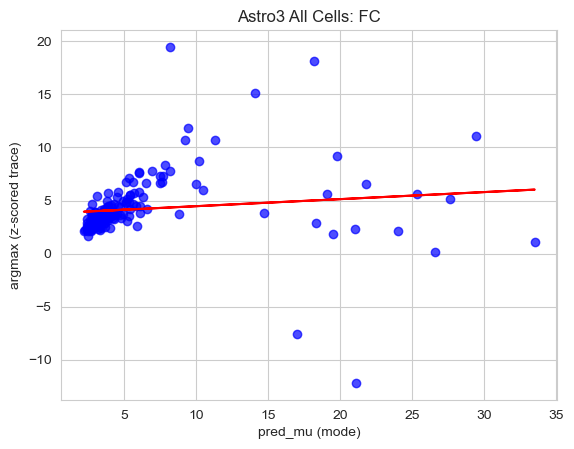

In [112]:
plt.scatter(mu_fc_animal['pred_mu'],resulting_times, color='blue', alpha=0.7)
# Add a line of best fit (linear regression)
# First, fit a linear regression model
coefficients = np.polyfit(mu_fc_animal['pred_mu'], resulting_times, 1)
poly = np.poly1d(coefficients)

# Plot the line of best fit
plt.plot(mu_fc_animal['pred_mu'], poly(mu_fc_animal['pred_mu']), color='red')

# Add labels and title
plt.xlabel('pred_mu (mode)')
plt.ylabel('argmax (z-scored trace)')
plt.title('Astro3 All Cells: FC')

# Display the plot
plt.savefig("/Users/suthardr/Desktop/Rui_models/astro3_fc_pred_mu_vs_argmax_MODE_Zscore.svg")

In [113]:
#Run spearman's correlation on x and y
rho, p = stats.spearmanr(mu_fc_animal['pred_mu'],resulting_times, axis=0)

#print Spearman rank correlation and p-value
print(rho)
print(p)

0.57362175623008Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
8.072647269187436e-16

